In [1]:
# CELL 1: IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import requests
import os
import time
import random
import json
import hashlib
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# LangSmith imports (optional)
try:
    from langsmith import Client, traceable
    LANGSMITH_AVAILABLE = True
except ImportError:
    print("⚠️ LangSmith not installed. Install with: pip install langsmith")
    LANGSMITH_AVAILABLE = False
    
    # Create dummy decorators for when LangSmith is not available
    def traceable(name=None):
        def decorator(func):
            return func
        return decorator

# Groq imports
try:
    from groq import Groq
    GROQ_AVAILABLE = True
    print("✅ Groq library available")
except ImportError:
    print("❌ Groq not installed. Install with: pip install groq")
    GROQ_AVAILABLE = False
    exit(1)

# Load environment variables
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("✅ Environment variables loaded")
except ImportError:
    print("📝 python-dotenv not found. Consider installing for .env file support")

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)

# ============================================================================
# CONFIGURATION CLASS
# ============================================================================

class Config:
    # Groq API Configuration
    GROQ_API_KEY = os.getenv('GROQ_API_KEY')
    
    # Primary reasoning models available on Groq
    MODEL = "openai/gpt-oss-20b"  # Primary reasoning model
    
    # Alternative models in preference order
    ALTERNATIVE_MODELS = [
        "deepseek-r1-distill-llama-70b",  # Groq's reasoning model
        "llama-3.3-70b-versatile",       # Fast fallback
        "llama-3.1-70b-versatile",       # Standard fallback
        "gemma2-9b-it"                   # Lightweight fallback
    ]
    
    # OpenAI models available on Groq (if you have access)
    OPENAI_ON_GROQ_MODELS = [
        "gpt-4o-mini",
        # "openai/gpt-oss-120b",  # Uncomment if available
        # "openai/gpt-oss-20b"    # Uncomment if available
    ]
    
    # LangSmith Configuration (Optional)
    LANGCHAIN_API_KEY = os.getenv('LANGCHAIN_API_KEY', None)
    LANGCHAIN_TRACING_V2 = "true"
    LANGCHAIN_PROJECT = os.getenv('LANGCHAIN_PROJECT', 'groq-reasoning-model-evaluation')
    LANGCHAIN_ENDPOINT = "https://api.smith.langchain.com"
    
    # Rate Limiting (Optimized for Groq)
    BASE_DELAY = 0.5               # Base delay between requests (Groq is generally faster)
    MAX_RETRIES = 3                # Retry attempts
    REQUEST_TIMEOUT = 60           # Timeout for requests
    BATCH_SIZE = 10                # Process in larger batches
    
    # Token limits (Groq-specific)
    MAX_COMPLETION_TOKENS = 1000   # Limit completion tokens
    
    # Testing Configuration
    SAMPLE_SIZE = 25              # Number of samples to test
    RANDOM_STATE = 42             # Reproducible results
    DATASET_PATH = "data/product_info_01.csv"
    PROMPTS_FOLDER = "prompts"
    
    # Results & Caching
    RESULTS_FOLDER = "results"
    CACHE_RESULTS = True          # Cache expensive API calls
    CACHE_FILE = os.path.join("cache", "groq_reasoning_cache.json")
    
    # Prompts to test (will be loaded from prompts folder)
    PROMPTS_TO_TEST = [
        "prompt_01"
    ]
    
    @classmethod
    def is_reasoning_model(cls, model: str) -> bool:
        """Check if model is a reasoning model"""
        reasoning_models = [
            "deepseek-r1-distill-llama-70b",
            "openai/gpt-oss-120b", 
            "openai/gpt-oss-20b"
        ]
        return any(rm in model.lower() for rm in reasoning_models)

config = Config()

# Validation
if not config.GROQ_API_KEY:
    print("❌ GROQ_API_KEY not found. Please set your Groq API key.")
    print("💡 Get your API key from: https://console.groq.com/keys")
    exit(1)

# ============================================================================
# LANGSMITH SETUP (OPTIONAL)
# ============================================================================

LANGSMITH_ENABLED = False
langsmith_client = None

if LANGSMITH_AVAILABLE and config.LANGCHAIN_API_KEY and config.LANGCHAIN_API_KEY != 'YOUR_LANGSMITH_API_KEY':
    try:
        os.environ["LANGCHAIN_API_KEY"] = config.LANGCHAIN_API_KEY
        os.environ["LANGCHAIN_TRACING_V2"] = config.LANGCHAIN_TRACING_V2
        os.environ["LANGCHAIN_PROJECT"] = config.LANGCHAIN_PROJECT
        os.environ["LANGCHAIN_ENDPOINT"] = config.LANGCHAIN_ENDPOINT
        
        # Initialize LangSmith client
        langsmith_client = Client()
        
        # Test connection
        langsmith_client.list_projects(limit=1)
        
        LANGSMITH_ENABLED = True
        print("✅ LangSmith observability enabled")
        
    except Exception as e:
        print(f"⚠️ LangSmith initialization failed: {e}")
        print("📝 Continuing without LangSmith observability")
        LANGSMITH_ENABLED = False
        langsmith_client = None
else:
    if not LANGSMITH_AVAILABLE:
        print("⚠️ LangSmith not available (not installed)")
    elif not config.LANGCHAIN_API_KEY:
        print("⚠️ LangSmith API key not provided")
    print("📝 Set LANGCHAIN_API_KEY environment variable to enable observability")
    print("📝 Continuing without LangSmith observability")
    LANGSMITH_ENABLED = False
    langsmith_client = None

# Initialize Groq client
try:
    groq_client = Groq(api_key=config.GROQ_API_KEY)
    print("✅ Groq client initialized")
    
    # Test connection by listing available models
    models = groq_client.models.list()
    available_models = [model.id for model in models.data]
    print(f"🤖 Available models: {len(available_models)}")
    
    # Check if our primary model is available
    if config.MODEL in available_models:
        print(f"✅ Primary model '{config.MODEL}' is available")
    else:
        print(f"⚠️ Primary model '{config.MODEL}' not found in available models")
        print(f"Available reasoning/large models: {[m for m in available_models if any(x in m.lower() for x in ['70b', 'deepseek', 'r1', 'reasoning'])]}")
        
except Exception as e:
    print(f"❌ Failed to initialize Groq client: {e}")
    exit(1)

print("\n" + "="*60)
print("✅ GROQ CONFIGURATION COMPLETE")
print("="*60)
print(f"🧠 Primary model: {config.MODEL}")
print(f"📊 Sample size: {config.SAMPLE_SIZE}")
print(f"💾 Caching: {config.CACHE_RESULTS}")
if LANGSMITH_ENABLED:
    print(f"🔍 LangSmith project: {config.LANGCHAIN_PROJECT}")
else:
    print("🔍 LangSmith: Disabled (optional - set LANGCHAIN_API_KEY to enable)")
print("="*60)

✅ Groq library available
✅ Environment variables loaded
✅ LangSmith observability enabled
✅ Groq client initialized
🤖 Available models: 23
✅ Primary model 'openai/gpt-oss-20b' is available

✅ GROQ CONFIGURATION COMPLETE
🧠 Primary model: openai/gpt-oss-20b
📊 Sample size: 25
💾 Caching: True
🔍 LangSmith project: reasoning-model-evaluation


In [2]:
# CELL 2: GROQ API CLIENT
# ============================================================================

class GroqReasoningAPIClient:
    """Groq API client with optional LangSmith observability"""
    
    def __init__(self):
        self.cache = {}
        self.load_cache()
        self.request_count = 0
        self.cache_hits = 0
        self.langsmith_enabled = LANGSMITH_ENABLED
        self.model_fallbacks = [config.MODEL] + config.ALTERNATIVE_MODELS
        
    def load_cache(self):
        """Load cached responses"""
        if config.CACHE_RESULTS and os.path.exists(config.CACHE_FILE):
            try:
                with open(config.CACHE_FILE, 'r', encoding='utf-8') as f:
                    self.cache = json.load(f)
                print(f"📂 Loaded {len(self.cache)} cached responses")
            except Exception as e:
                print(f"⚠️ Cache load error: {e}")
                self.cache = {}
    
    def save_cache(self):
        """Save cache to disk"""
        if config.CACHE_RESULTS:
            try:
                cache_dir = os.path.dirname(config.CACHE_FILE)
                if cache_dir:
                    os.makedirs(cache_dir, exist_ok=True)
                
                with open(config.CACHE_FILE, 'w', encoding='utf-8') as f:
                    json.dump(self.cache, f, indent=2, ensure_ascii=False)
            except Exception as e:
                print(f"⚠️ Cache save error: {e}")
    
    def get_cache_key(self, prompt: str, product: str, model: str) -> str:
        """Generate cache key including model"""
        content = f"{model}||{prompt}||{product}"
        return hashlib.md5(content.encode()).hexdigest()
    
    def classify_product(self, product_description: str, system_prompt: str, 
                        true_category: str = None, prompt_name: str = None) -> dict:
        """Classify product with optional LangSmith tracing"""
        
        # Apply tracing decorator if LangSmith is enabled
        if self.langsmith_enabled:
            return self._classify_product_traced(product_description, system_prompt, true_category, prompt_name)
        else:
            return self._classify_product_basic(product_description, system_prompt, true_category, prompt_name)
    
    def _classify_product_traced(self, product_description: str, system_prompt: str, 
                               true_category: str = None, prompt_name: str = None) -> dict:
        """Classify product with LangSmith tracing (when enabled)"""
        
        @traceable(name="groq_product_classification")
        def _inner():
            return self._classify_product_core(product_description, system_prompt, true_category, prompt_name)
        
        return _inner()
    
    def _classify_product_basic(self, product_description: str, system_prompt: str, 
                              true_category: str = None, prompt_name: str = None) -> dict:
        """Classify product without tracing (when LangSmith disabled)"""
        return self._classify_product_core(product_description, system_prompt, true_category, prompt_name)
    
    def _classify_product_core(self, product_description: str, system_prompt: str, 
                             true_category: str = None, prompt_name: str = None) -> dict:
        """Core classification logic"""
        
        # Check cache first
        cache_key = self.get_cache_key(system_prompt, product_description, config.MODEL)
        if config.CACHE_RESULTS and cache_key in self.cache:
            self.cache_hits += 1
            cached_result = self.cache[cache_key]
            
            return self._add_metadata(
                cached_result, product_description, true_category, 
                prompt_name, from_cache=True
            )
        
        # Prepare prompt for reasoning model
        full_prompt = self._prepare_reasoning_prompt(system_prompt, product_description)
        
        # Make API request with fallbacks
        try:
            result = self._make_api_call_with_fallbacks(
                full_prompt, product_description, true_category, prompt_name
            )
            
            # Cache result
            if config.CACHE_RESULTS:
                self.cache[cache_key] = result
                self.save_cache()
            
            return result
            
        except Exception as e:
            print(f"❌ API Error: {e}")
            error_result = {
                'predicted_category': 'error',
                'raw_response': str(e),
                'status': 'error'
            }
            return self._add_metadata(
                error_result, product_description, true_category, prompt_name
            )
    
    def _prepare_reasoning_prompt(self, system_prompt: str, product_description: str) -> str:
        """Prepare prompt for reasoning models"""
        
        if config.is_reasoning_model(config.MODEL):
            # For reasoning models, provide more structured thinking guidance
            return f"""{system_prompt}

Product to classify: {product_description}

Please think through this classification step by step:

1. First, analyze the key features and characteristics of this product
2. Consider which main category it belongs to (body, skin, hair, etc.)
3. Determine the appropriate subcategory
4. Identify the specific type if applicable

Then provide ONLY the final category path as your answer in this exact format: category/subcategory/specific-type

Examples of correct format:
- body/female-intimate-hygiene
- skin/moisturisers/normal-skin  
- hair/shampoo/oily-hair

Your final answer should be just the category path, nothing else."""
        else:
            # For non-reasoning models, use simpler prompt
            return f"""{system_prompt}

Product to classify: {product_description}

Please provide ONLY the category path in this format: category/subcategory/specific-type

Examples:
- body/female-intimate-hygiene
- skin/moisturisers/normal-skin
- hair/shampoo/oily-hair"""
    
    def _make_api_call_with_fallbacks(self, prompt: str, product_description: str, 
                                     true_category: str, prompt_name: str) -> dict:
        """Make API call with model fallbacks"""
        
        last_error = None
        
        for model in self.model_fallbacks:
            try:
                return self._make_groq_api_call(
                    prompt, product_description, true_category, prompt_name, model
                )
            except Exception as e:
                last_error = e
                print(f"⚠️ Model {model} failed, trying next...")
                time.sleep(1)  # Brief pause between fallbacks
        
        # If all models fail
        raise last_error or Exception("All model fallbacks failed")
    
    def _make_groq_api_call(self, prompt: str, product_description: str, 
                           true_category: str, prompt_name: str, model: str) -> dict:
        """Make API call to Groq"""
        
        if self.langsmith_enabled:
            return self._make_traced_groq_call(prompt, product_description, true_category, prompt_name, model)
        else:
            return self._make_basic_groq_call(prompt, product_description, true_category, prompt_name, model)
    
    def _make_traced_groq_call(self, prompt: str, product_description: str, 
                              true_category: str, prompt_name: str, model: str) -> dict:
        """Make Groq API call with LangSmith tracing"""
        
        @traceable(name="groq_api_call")
        def _inner():
            return self._make_groq_call_core(prompt, product_description, true_category, prompt_name, model)
        
        return _inner()
    
    def _make_basic_groq_call(self, prompt: str, product_description: str, 
                             true_category: str, prompt_name: str, model: str) -> dict:
        """Make Groq API call without tracing"""
        return self._make_groq_call_core(prompt, product_description, true_category, prompt_name, model)
    
    def _make_groq_call_core(self, prompt: str, product_description: str, 
                            true_category: str, prompt_name: str, model: str) -> dict:
        """Core Groq API call logic"""
        
        self.request_count += 1
        start_time = time.time()
        
        try:
            # Make request to Groq
            response = groq_client.chat.completions.create(
                model=model,
                messages=[
                    {
                        "role": "user", 
                        "content": prompt
                    }
                ],
                max_tokens=config.MAX_COMPLETION_TOKENS,
                temperature=0.1,  # Low temperature for consistent reasoning
                top_p=0.9,
            )
            
            end_time = time.time()
            content = response.choices[0].message.content
            category = self._extract_category(content)
            
            # Calculate metrics
            exact_match = (true_category and category.strip() == true_category.strip())
            partial_match = (true_category and '/' in category and 
                           true_category.split('/')[0] == category.split('/')[0])
            
            result = {
                'predicted_category': category,
                'raw_response': content,
                'model_used': response.model,
                'usage': {
                    'prompt_tokens': response.usage.prompt_tokens if response.usage else 0,
                    'completion_tokens': response.usage.completion_tokens if response.usage else 0,
                    'total_tokens': response.usage.total_tokens if response.usage else 0
                },
                'status': 'success',
                'latency': end_time - start_time,
                'exact_match': exact_match,
                'partial_match': partial_match
            }
            
            return self._add_metadata(
                result, product_description, true_category, prompt_name
            )
            
        except Exception as e:
            end_time = time.time()
            error_result = {
                'predicted_category': 'error',
                'raw_response': str(e),
                'status': 'error',
                'latency': end_time - start_time,
                'model_used': model
            }
            return self._add_metadata(
                error_result, product_description, true_category, prompt_name
            )
    
    def _add_metadata(self, result: dict, product_description: str, 
                     true_category: str, prompt_name: str, 
                     from_cache: bool = False) -> dict:
        """Add metadata for tracking"""
        
        # Calculate accuracy metrics
        if true_category and result.get('predicted_category') != 'error':
            predicted = result['predicted_category']
            result['exact_match'] = predicted.strip() == true_category.strip()
            result['partial_match'] = ('/' in predicted and 
                                     true_category.split('/')[0] == predicted.split('/')[0])
        
        # Add metadata
        result.update({
            'true_category': true_category,
            'product_description': product_description[:200] + "..." if len(product_description) > 200 else product_description,
            'prompt_name': prompt_name,
            'model': result.get('model_used', config.MODEL),
            'from_cache': from_cache,
            'timestamp': datetime.now().isoformat(),
            'langsmith_enabled': self.langsmith_enabled,
            'api_provider': 'groq'
        })
        
        return result
    
    def _extract_category(self, response: str) -> str:
        """Extract category from response"""
        import re
        
        response = response.strip()
        lines = response.split('\n')
        
        # Look for category patterns
        category_pattern = re.compile(r'^[a-zA-Z0-9\-_]+(?:/[a-zA-Z0-9\-_]+)*$')
        
        # First, look for lines that are pure category paths
        for line in lines:
            line = line.strip()
            if category_pattern.match(line) and '/' in line:
                return line
        
        # Try extracting from anywhere in text  
        category_matches = re.findall(r'\b[a-z\-]+(?:/[a-z\-]+)+\b', response.lower())
        if category_matches:
            return category_matches[0]
        
        # Look for lines that might be answers
        answer_keywords = ['answer:', 'category:', 'classification:', 'result:']
        for line in lines:
            line_lower = line.lower().strip()
            for keyword in answer_keywords:
                if line_lower.startswith(keyword):
                    remaining = line[len(keyword):].strip()
                    if '/' in remaining and category_pattern.match(remaining):
                        return remaining
        
        # Last resort - return first non-empty line that contains a slash
        for line in reversed(lines):
            line = line.strip()
            if '/' in line and len(line.split()) <= 3:  # Likely a category path
                # Clean up common prefixes
                for prefix in ['answer:', 'category:', 'classification:', 'result:', 'final answer:']:
                    if line.lower().startswith(prefix):
                        line = line[len(prefix):].strip()
                        break
                return line
        
        return response.split('\n')[0] if '\n' in response else response
    
    def get_stats(self) -> dict:
        """Get API usage statistics"""
        return {
            'requests_made': self.request_count,
            'cache_hits': self.cache_hits,
            'cache_size': len(self.cache),
            'hit_rate': f"{(self.cache_hits / max(1, self.request_count + self.cache_hits) * 100):.1f}%",
            'langsmith_enabled': self.langsmith_enabled,
            'primary_model': config.MODEL,
            'api_provider': 'groq'
        }

# Initialize Groq API client
api_client = GroqReasoningAPIClient()

print("✅ Groq API client initialized")
print(f"📊 Stats: {api_client.get_stats()}")

📂 Loaded 789 cached responses
✅ Groq API client initialized
📊 Stats: {'requests_made': 0, 'cache_hits': 0, 'cache_size': 789, 'hit_rate': '0.0%', 'langsmith_enabled': True, 'primary_model': 'openai/gpt-oss-20b', 'api_provider': 'groq'}


In [3]:
# CELL 3: UTILITY FUNCTIONS
# ============================================================================

def load_prompt(prompt_name: str) -> str:
    """Load prompt from prompts folder"""
    try:
        prompt_path = os.path.join(config.PROMPTS_FOLDER, f"{prompt_name}.md")
        with open(prompt_path, 'r', encoding='utf-8') as f:
            content = f.read().strip()
        
        if not content:
            raise ValueError(f"Empty prompt file: {prompt_name}")
        
        return content
    except FileNotFoundError:
        print(f"❌ Prompt file not found: {prompt_path}")
        return ""
    except Exception as e:
        print(f"❌ Error loading prompt {prompt_name}: {e}")
        return ""

def load_dataset():
    """Load and prepare dataset"""
    try:
        # Try different encodings and separators
        encodings = ['utf-8', 'ISO-8859-1', 'cp1252']
        separators = [',', ';', '\t']
        
        df = None
        for encoding in encodings:
            for sep in separators:
                try:
                    df = pd.read_csv(config.DATASET_PATH, encoding=encoding, sep=sep)
                    if 'brand' in df.columns and 'itemDescriptionEN' in df.columns:
                        break
                except:
                    continue
            if df is not None:
                break
        
        if df is None:
            raise Exception("Could not load dataset with any encoding/separator combination")
        
        # Create concatenated product description
        df['concatenated_product'] = (df['brand'].astype(str) + '-' + 
                                    df['itemDescriptionEN'].astype(str) + '-' + 
                                    df['description'].astype(str))
        
        # Clean data
        df = df.dropna(subset=['concatenated_product', 'encodeNameEN'])
        
        print(f"✅ Dataset loaded: {df.shape[0]} products")
        return df
        
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None

def calculate_metrics(true_categories: list, predicted_categories: list) -> dict:
    """Calculate evaluation metrics"""
    
    # Filter valid predictions
    valid_pairs = [(t, p) for t, p in zip(true_categories, predicted_categories) 
                   if p and p != 'error' and '/' in p]
    
    if not valid_pairs:
        return {
            'exact_accuracy': 0.0,
            'partial_accuracy': 0.0,
            'valid_predictions': 0,
            'error_count': len(predicted_categories)
        }
    
    valid_true, valid_predicted = zip(*valid_pairs)
    
    # Exact matches
    exact_matches = sum(1 for t, p in valid_pairs if t.strip() == p.strip())
    exact_accuracy = exact_matches / len(valid_pairs)
    
    # Partial matches
    partial_matches = sum(1 for t, p in valid_pairs 
                         if t.split('/')[0] == p.split('/')[0])
    partial_accuracy = partial_matches / len(valid_pairs)
    
    return {
        'exact_accuracy': exact_accuracy,
        'partial_accuracy': partial_accuracy,
        'exact_matches': exact_matches,
        'partial_matches': partial_matches,
        'valid_predictions': len(valid_pairs),
        'error_count': len(predicted_categories) - len(valid_pairs)
    }

def evaluate_single_prompt(prompt_name: str, test_data: pd.DataFrame, verbose: bool = True):
    """Evaluate single prompt with optional LangSmith tracing"""
    
    # Apply tracing decorator if LangSmith is enabled
    if LANGSMITH_ENABLED:
        @traceable(name="groq_single_prompt_evaluation")
        def _evaluate():
            return _evaluate_single_prompt_core(prompt_name, test_data, verbose)
        return _evaluate()
    else:
        return _evaluate_single_prompt_core(prompt_name, test_data, verbose)

def _evaluate_single_prompt_core(prompt_name: str, test_data: pd.DataFrame, verbose: bool = True):
    """Core evaluation logic"""
    
    if verbose:
        print(f"\n🧪 EVALUATING: {prompt_name}")
        print("=" * 60)
    
    # Load prompt
    system_prompt = load_prompt(prompt_name)
    if not system_prompt:
        print(f"❌ Could not load prompt: {prompt_name}")
        return None
    
    if verbose:
        print(f"📝 Prompt loaded ({len(system_prompt)} chars)")
        print(f"🔄 Processing {len(test_data)} products with Groq...")
    
    results = []
    products = test_data['concatenated_product'].tolist()
    true_categories = test_data['encodeNameEN'].tolist()
    
    # Create evaluation metadata
    evaluation_metadata = {
        'prompt_name': prompt_name,
        'sample_size': len(test_data),
        'model': config.MODEL,
        'timestamp': datetime.now().isoformat(),
        'langsmith_enabled': LANGSMITH_ENABLED,
        'api_provider': 'groq'
    }
    
    # Process each product
    for i, (product, true_cat) in enumerate(zip(products, true_categories)):
        if verbose and i % 5 == 0:  # More frequent updates since Groq is faster
            print(f"   Progress: {i+1}/{len(products)} ({(i+1)/len(products)*100:.0f}%)")
        
        # Classify product with tracing
        result = api_client.classify_product(
            product_description=product,
            system_prompt=system_prompt,
            true_category=true_cat,
            prompt_name=prompt_name
        )
        
        results.append(result)
        
        # Rate limiting (shorter delay for Groq)
        if not result.get('from_cache', False):
            time.sleep(config.BASE_DELAY)
    
    # Calculate metrics
    predicted_cats = [r['predicted_category'] for r in results]
    metrics = calculate_metrics(true_categories, predicted_cats)
    
    # Log evaluation metrics to LangSmith (if enabled)
    if LANGSMITH_ENABLED and langsmith_client:
        try:
            langsmith_client.create_feedback(
                run_id=None,
                key="groq_evaluation_metrics",
                score=metrics['exact_accuracy'],
                value={
                    'exact_accuracy': metrics['exact_accuracy'],
                    'partial_accuracy': metrics['partial_accuracy'],
                    'valid_predictions': metrics['valid_predictions'],
                    'error_count': metrics['error_count'],
                    'prompt_name': prompt_name,
                    'model': config.MODEL,
                    'api_provider': 'groq'
                }
            )
        except Exception as e:
            print(f"⚠️ Failed to log metrics to LangSmith: {e}")
    
    if verbose:
        print(f"\n📊 RESULTS (Groq {config.MODEL}):")
        print(f"   ✅ Exact accuracy: {metrics['exact_accuracy']:.1%}")
        print(f"   📊 Partial accuracy: {metrics['partial_accuracy']:.1%}")
        print(f"   🎯 Valid predictions: {metrics['valid_predictions']}")
        print(f"   ❌ Errors: {metrics['error_count']}")
        
        if LANGSMITH_ENABLED:
            print(f"   🔍 Tracked in LangSmith project: {config.LANGCHAIN_PROJECT}")
        else:
            print(f"   📝 LangSmith observability: Disabled")
        
        # Show examples
        print(f"\n💡 Examples:")
        for result in results[:3]:
            status = "✅" if result.get('exact_match', False) else "❌"
            print(f"   {status} {result['true_category']} → {result['predicted_category']}")
    
    return {
        'prompt_name': prompt_name,
        'metrics': metrics,
        'results': results,
        'api_stats': api_client.get_stats(),
        'evaluation_metadata': evaluation_metadata
    }

def compare_all_prompts(test_data: pd.DataFrame):
    """Compare multiple prompts with optional LangSmith tracing"""
    
    # Apply tracing decorator if LangSmith is enabled
    if LANGSMITH_ENABLED:
        @traceable(name="groq_multi_prompt_comparison")
        def _compare():
            return _compare_all_prompts_core(test_data)
        return _compare()
    else:
        return _compare_all_prompts_core(test_data)

def _compare_all_prompts_core(test_data: pd.DataFrame):
    """Core comparison logic"""
    
    print(f"\n🏁 MULTI-PROMPT EVALUATION (GROQ)")
    print("=" * 60)
    print(f"📊 Testing {len(config.PROMPTS_TO_TEST)} prompts on {len(test_data)} products")
    print(f"🧠 Using Groq model: {config.MODEL}")
    
    if LANGSMITH_ENABLED:
        print(f"🔍 Tracking in LangSmith project: {config.LANGCHAIN_PROJECT}")
    else:
        print(f"📝 LangSmith observability: Disabled")
    
    all_results = []
    
    for i, prompt_name in enumerate(config.PROMPTS_TO_TEST):
        print(f"\n🔄 [{i+1}/{len(config.PROMPTS_TO_TEST)}] Evaluating: {prompt_name}")
        
        result = evaluate_single_prompt(prompt_name, test_data, verbose=False)
        if result:
            all_results.append(result)
            metrics = result['metrics']
            print(f"   ✅ Exact: {metrics['exact_accuracy']:.1%} | "
                  f"Partial: {metrics['partial_accuracy']:.1%} | "
                  f"Errors: {metrics['error_count']}")
    
    if not all_results:
        print("❌ No successful evaluations")
        return None
    
    # Create comparison summary
    comparison_data = []
    for result in all_results:
        metrics = result['metrics']
        comparison_data.append({
            'Prompt': result['prompt_name'],
            'Exact_Accuracy': f"{metrics['exact_accuracy']:.1%}",
            'Partial_Accuracy': f"{metrics['partial_accuracy']:.1%}",
            'Valid_Predictions': metrics['valid_predictions'],
            'Errors': metrics['error_count']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print(f"\n📊 GROQ COMPARISON RESULTS")
    print("=" * 60)
    display(comparison_df)
    
    # Best performing prompt
    best_result = max(all_results, key=lambda x: x['metrics']['exact_accuracy'])
    best_metrics = best_result['metrics']
    
    print(f"\n🏆 BEST PROMPT: {best_result['prompt_name']}")
    print(f"   📈 Exact accuracy: {best_metrics['exact_accuracy']:.1%}")
    print(f"   📊 Partial accuracy: {best_metrics['partial_accuracy']:.1%}")
    
    # API usage summary
    final_stats = api_client.get_stats()
    print(f"\n💰 GROQ API USAGE:")
    print(f"   📞 Total requests: {final_stats['requests_made']}")
    print(f"   💾 Cache hits: {final_stats['cache_hits']} ({final_stats['hit_rate']})")
    
    if LANGSMITH_ENABLED:
        print(f"\n🔍 VIEW DETAILED TRACES:")
        print(f"   🌐 LangSmith URL: https://smith.langchain.com/projects/{config.LANGCHAIN_PROJECT}")
    else:
        print(f"\n📝 To enable detailed tracing, set your LANGCHAIN_API_KEY environment variable")
    
    return {
        'comparison_df': comparison_df,
        'all_results': all_results,
        'best_result': best_result
    }

def export_results_with_langsmith(comparison_results: dict):
    """Export evaluation results with optional LangSmith links"""
    
    if not comparison_results:
        print("❌ No results to export")
        return
    
    # Create results directory
    os.makedirs(config.RESULTS_FOLDER, exist_ok=True)
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_filename = f"groq_evaluation_{timestamp}"
    if LANGSMITH_ENABLED:
        base_filename = f"langsmith_{base_filename}"
    
    try:
        # Export summary
        summary_path = os.path.join(config.RESULTS_FOLDER, f"{base_filename}_summary.csv")
        comparison_results['comparison_df'].to_csv(summary_path, index=False)
        print(f"✅ Summary exported: {summary_path}")
        
        # Export detailed results
        all_detailed = []
        for result in comparison_results['all_results']:
            all_detailed.extend(result['results'])
        
        detailed_df = pd.DataFrame(all_detailed)
        detailed_path = os.path.join(config.RESULTS_FOLDER, f"{base_filename}_detailed.csv")
        detailed_df.to_csv(detailed_path, index=False)
        print(f"✅ Detailed results exported: {detailed_path}")
        
        # Export configuration and stats
        config_info = {
            'model': config.MODEL,
            'sample_size': config.SAMPLE_SIZE,
            'prompts_tested': config.PROMPTS_TO_TEST,
            'timestamp': datetime.now().isoformat(),
            'api_stats': api_client.get_stats(),
            'langsmith_enabled': LANGSMITH_ENABLED,
            'api_provider': 'groq',
            'fallback_models': config.ALTERNATIVE_MODELS
        }
        
        # Add LangSmith info if enabled
        if LANGSMITH_ENABLED:
            config_info.update({
                'langsmith_project': config.LANGCHAIN_PROJECT,
                'langsmith_url': f"https://smith.langchain.com/projects/{config.LANGCHAIN_PROJECT}"
            })
        
        config_path = os.path.join(config.RESULTS_FOLDER, f"{base_filename}_config.json")
        with open(config_path, 'w') as f:
            json.dump(config_info, f, indent=2)
        print(f"✅ Configuration exported: {config_path}")
        
        print(f"\n📁 All results saved to: {config.RESULTS_FOLDER}/")
        
        if LANGSMITH_ENABLED:
            print(f"🔍 LangSmith traces: https://smith.langchain.com/projects/{config.LANGCHAIN_PROJECT}")
        else:
            print(f"📝 To enable LangSmith observability, set LANGCHAIN_API_KEY environment variable")
        
    except Exception as e:
        print(f"❌ Export error: {e}")

print("✅ Groq evaluation functions loaded")

✅ Groq evaluation functions loaded


In [4]:
# CELL 4: LOAD DATA AND PREVIEW
# ============================================================================

print("\n" + "="*60)
print("📊 LOADING AND PREVIEWING DATA")
print("="*60)

# Load dataset
df = load_dataset()

if df is not None:
    # Sample for testing
    test_df = df.sample(n=min(config.SAMPLE_SIZE, len(df)), random_state=config.RANDOM_STATE)
    
    print(f"\n📊 Test sample: {len(test_df)} products")
    print(f"📋 Categories in sample: {test_df['encodeNameEN'].nunique()}")
    
    # Show preview
    print("\n📋 Sample data:")
    display(test_df[['encodeNameEN', 'concatenated_product']].head())
    
    # Category distribution
    print(f"\n📊 Top categories in sample:")
    top_categories = test_df['encodeNameEN'].value_counts().head(10)
    for cat, count in top_categories.items():
        print(f"  • {cat}: {count}")
        
    print(f"\n✅ Data ready for Groq evaluation")
else:
    print("❌ Failed to load data")


📊 LOADING AND PREVIEWING DATA
✅ Dataset loaded: 15966 products

📊 Test sample: 25 products
📋 Categories in sample: 23

📋 Sample data:


,encodeNameEN,concatenated_product
6992,sun-tan/eyes-lips-sensitive-areas,Babe-Fotoprotector Lip Protection SPF50 Invisible -Fotoprotector Lip Protection SPF50 Invisiblea...
14395,skin/dark-spots/seruns,Rilastil-Intense C Gel Serum-Intense C Gel Serum is a protective serum specially formulated for ...
10432,health-care/contact-lenses,"Montana Eyewear-Blue Light Filter Glasses HBLF73A Turtle -Lightweight, practical and very comfor..."
12134,hair/seruns-leave-in/sensitive-scalp,Lador-Tea Tree Scalp Clinic Hair Pack-Experience the soothing benefits of Tea Tree Scalp Clinic ...
10169,skin/loss-firmness/specific-moisturizers,Roc-Multi Correxion Firm + Lift Firming Cream-Restore facial firmness and redefine contours with...



📊 Top categories in sample:
  • skin/dark-spots/seruns: 2
  • skin/dehydration/specific-moisturizers: 2
  • sun-tan/eyes-lips-sensitive-areas: 1
  • hair/seruns-leave-in/sensitive-scalp: 1
  • skin/loss-firmness/specific-moisturizers: 1
  • hair/hair-mask/straightening: 1
  • health-care/contact-lenses: 1
  • fragrance/women: 1
  • skin/cleansers-tonners/combination-to-oily-skin: 1
  • makeup/complexion/makeup-removers: 1

✅ Data ready for Groq evaluation


In [5]:
# CELL 5: RUN SINGLE PROMPT EVALUATION (EXAMPLE)
# ============================================================================

print("\n" + "="*60)
print("🧪 SINGLE PROMPT EVALUATION EXAMPLE (GROQ)")
print("="*60)

# Example: Evaluate first prompt (if data loaded successfully)
if 'df' in locals() and df is not None and len(config.PROMPTS_TO_TEST) > 0:
    first_prompt = config.PROMPTS_TO_TEST[0]
    print(f"Testing with Groq model: {config.MODEL}")
    print(f"Testing with prompt: {first_prompt}")
    
    # Run single evaluation
    single_result = evaluate_single_prompt(first_prompt, test_df)
    
    if single_result:
        print(f"\n🎉 Single evaluation completed!")
        print(f"📊 Results saved in variable 'single_result'")
    else:
        print(f"❌ Single evaluation failed")
else:
    print("❌ Cannot run evaluation - data not loaded or no prompts configured")


🧪 SINGLE PROMPT EVALUATION EXAMPLE (GROQ)
Testing with Groq model: openai/gpt-oss-20b
Testing with prompt: prompt_01

🧪 EVALUATING: prompt_01
📝 Prompt loaded (12993 chars)
🔄 Processing 25 products with Groq...
   Progress: 1/25 (4%)
   Progress: 6/25 (24%)
   Progress: 11/25 (44%)
   Progress: 16/25 (64%)
   Progress: 21/25 (84%)
⚠️ Failed to log metrics to LangSmith: One of run_id, trace_id, or project_id  must be provided

📊 RESULTS (Groq openai/gpt-oss-20b):
   ✅ Exact accuracy: 42.9%
   📊 Partial accuracy: 85.7%
   🎯 Valid predictions: 21
   ❌ Errors: 4
   🔍 Tracked in LangSmith project: reasoning-model-evaluation

💡 Examples:
   ❌ sun-tan/eyes-lips-sensitive-areas → skin/lip-care/dryness-dehydration
   ❌ skin/dark-spots/seruns → 
   ❌ health-care/contact-lenses → 

🎉 Single evaluation completed!
📊 Results saved in variable 'single_result'


In [6]:
# CELL 6: RUN MULTI-PROMPT COMPARISON
# ============================================================================

print("\n" + "="*60)
print("🏁 MULTI-PROMPT COMPARISON (GROQ)")
print("="*60)

# Run comparison if data is available
if 'df' in locals() and df is not None:
    print(f"🚀 Starting comprehensive Groq evaluation...")
    comparison_results = compare_all_prompts(test_df)
    
    if comparison_results:
        print(f"\n🎉 Multi-prompt evaluation completed!")
        print(f"📊 Results saved in variable 'comparison_results'")
    else:
        print(f"❌ Multi-prompt evaluation failed")
else:
    print("❌ Cannot run comparison - data not loaded")


🏁 MULTI-PROMPT COMPARISON (GROQ)
🚀 Starting comprehensive Groq evaluation...

🏁 MULTI-PROMPT EVALUATION (GROQ)
📊 Testing 1 prompts on 25 products
🧠 Using Groq model: openai/gpt-oss-20b
🔍 Tracking in LangSmith project: reasoning-model-evaluation

🔄 [1/1] Evaluating: prompt_01
⚠️ Failed to log metrics to LangSmith: One of run_id, trace_id, or project_id  must be provided
   ✅ Exact: 42.9% | Partial: 85.7% | Errors: 4

📊 GROQ COMPARISON RESULTS


,Prompt,Exact_Accuracy,Partial_Accuracy,Valid_Predictions,Errors
0,prompt_01,42.9%,85.7%,21,4



🏆 BEST PROMPT: prompt_01
   📈 Exact accuracy: 42.9%
   📊 Partial accuracy: 85.7%

💰 GROQ API USAGE:
   📞 Total requests: 25
   💾 Cache hits: 25 (50.0%)

🔍 VIEW DETAILED TRACES:
   🌐 LangSmith URL: https://smith.langchain.com/projects/reasoning-model-evaluation

🎉 Multi-prompt evaluation completed!
📊 Results saved in variable 'comparison_results'


In [7]:
# CELL 7: EXPORT RESULTS
# ============================================================================

print("\n" + "="*60)
print("📁 EXPORTING RESULTS")
print("="*60)

# Export results if comparison was successful
if 'comparison_results' in locals() and comparison_results:
    print("🔄 Exporting Groq results...")
    export_results_with_langsmith(comparison_results)
    print("\n🎉 Export completed!")
else:
    print("❌ No results to export - run evaluations first")


📁 EXPORTING RESULTS
🔄 Exporting Groq results...
✅ Summary exported: results\langsmith_groq_evaluation_20250807_151908_summary.csv
✅ Detailed results exported: results\langsmith_groq_evaluation_20250807_151908_detailed.csv
✅ Configuration exported: results\langsmith_groq_evaluation_20250807_151908_config.json

📁 All results saved to: results/
🔍 LangSmith traces: https://smith.langchain.com/projects/reasoning-model-evaluation

🎉 Export completed!


In [8]:
# CELL 8: ADVANCED ANALYSIS AND VISUALIZATION FUNCTIONS
# ============================================================================

def create_visualizations(comparison_results: dict):
    """Create visualizations of Groq evaluation results"""
    
    if not comparison_results:
        print("❌ No results to visualize")
        return
    
    # Set up matplotlib
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Groq Reasoning Model Evaluation Results', fontsize=16, fontweight='bold')
    
    # Extract data for visualization
    prompts = [result['prompt_name'] for result in comparison_results['all_results']]
    exact_acc = [result['metrics']['exact_accuracy'] for result in comparison_results['all_results']]
    partial_acc = [result['metrics']['partial_accuracy'] for result in comparison_results['all_results']]
    errors = [result['metrics']['error_count'] for result in comparison_results['all_results']]
    
    # 1. Accuracy Comparison
    x = range(len(prompts))
    width = 0.35
    
    axes[0, 0].bar([i - width/2 for i in x], exact_acc, width, label='Exact Accuracy', color='#2E86C1')
    axes[0, 0].bar([i + width/2 for i in x], partial_acc, width, label='Partial Accuracy', color='#58D68D')
    axes[0, 0].set_xlabel('Prompts')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title(f'Accuracy Comparison ({config.MODEL})')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(prompts, rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Error Analysis
    axes[0, 1].bar(prompts, errors, color='#E74C3C')
    axes[0, 1].set_xlabel('Prompts')
    axes[0, 1].set_ylabel('Error Count')
    axes[0, 1].set_title('Error Analysis')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Performance Scatter
    valid_preds = [result['metrics']['valid_predictions'] for result in comparison_results['all_results']]
    colors = ['#E74C3C' if e > 0 else '#27AE60' for e in errors]
    
    scatter = axes[1, 0].scatter(exact_acc, partial_acc, s=[100 + v*2 for v in valid_preds], 
                                c=colors, alpha=0.6, edgecolors='black')
    axes[1, 0].set_xlabel('Exact Accuracy')
    axes[1, 0].set_ylabel('Partial Accuracy')
    axes[1, 0].set_title('Accuracy Correlation (size = valid predictions)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add labels
    for i, prompt in enumerate(prompts):
        axes[1, 0].annotate(prompt, (exact_acc[i], partial_acc[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # 4. API Usage Statistics
    api_stats = api_client.get_stats()
    cache_data = [api_stats['cache_hits'], api_stats['requests_made'] - api_stats['cache_hits']]
    labels = ['Cache Hits', 'Fresh Requests']
    colors_pie = ['#58D68D', '#3498DB']
    
    axes[1, 1].pie(cache_data, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Groq API Cache Effectiveness')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n📊 GROQ SUMMARY STATISTICS")
    print("="*40)
    best_result = comparison_results['best_result']
    print(f"🏆 Best Prompt: {best_result['prompt_name']}")
    print(f"📈 Best Exact Accuracy: {best_result['metrics']['exact_accuracy']:.1%}")
    print(f"📊 Average Exact Accuracy: {sum(exact_acc)/len(exact_acc):.1%}")
    print(f"📊 Average Partial Accuracy: {sum(partial_acc)/len(partial_acc):.1%}")
    print(f"💰 Total API Requests: {api_stats['requests_made']}")
    print(f"💾 Cache Efficiency: {api_stats['hit_rate']}")
    print(f"🧠 Model Used: {config.MODEL}")

def analyze_error_patterns(comparison_results: dict):
    """Analyze common error patterns in Groq results"""
    
    if not comparison_results:
        print("❌ No results to analyze")
        return
    
    print("\n🔍 GROQ ERROR PATTERN ANALYSIS")
    print("="*40)
    
    all_results = []
    for result in comparison_results['all_results']:
        all_results.extend(result['results'])
    
    # Analyze errors
    error_results = [r for r in all_results if r['predicted_category'] == 'error']
    invalid_format = [r for r in all_results if r['predicted_category'] != 'error' and '/' not in r['predicted_category']]
    
    print(f"❌ Total Errors: {len(error_results)}")
    print(f"🚫 Invalid Format: {len(invalid_format)}")
    
    # Show reasoning model specific insights
    reasoning_results = [r for r in all_results if config.is_reasoning_model(r.get('model_used', ''))]
    non_reasoning_results = [r for r in all_results if not config.is_reasoning_model(r.get('model_used', ''))]
    
    if reasoning_results:
        print(f"\n🧠 Reasoning Model Results: {len(reasoning_results)}")
        reasoning_accuracy = sum(1 for r in reasoning_results if r.get('exact_match', False)) / len(reasoning_results)
        print(f"   📈 Reasoning Model Accuracy: {reasoning_accuracy:.1%}")
    
    if non_reasoning_results:
        print(f"🤖 Non-Reasoning Model Results: {len(non_reasoning_results)}")
        non_reasoning_accuracy = sum(1 for r in non_reasoning_results if r.get('exact_match', False)) / len(non_reasoning_results)
        print(f"   📈 Non-Reasoning Model Accuracy: {non_reasoning_accuracy:.1%}")
    
    if error_results:
        print("\n🔍 Sample Error Messages:")
        for i, error in enumerate(error_results[:3]):
            print(f"   {i+1}. {error['raw_response'][:100]}...")
    
    # Analyze partial matches vs exact matches
    exact_matches = [r for r in all_results if r.get('exact_match', False)]
    partial_only = [r for r in all_results if r.get('partial_match', False) and not r.get('exact_match', False)]
    
    print(f"\n✅ Exact Matches: {len(exact_matches)}")
    print(f"📊 Partial Only: {len(partial_only)}")
    
    if partial_only:
        print("\n🔍 Common Partial Match Patterns:")
        partial_categories = {}
        for r in partial_only:
            true_cat = r['true_category'].split('/')[0] if r['true_category'] else 'unknown'
            partial_categories[true_cat] = partial_categories.get(true_cat, 0) + 1
        
        for cat, count in sorted(partial_categories.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"   • {cat}: {count} partial matches")

def create_detailed_report(comparison_results: dict):
    """Create a detailed text report of the Groq evaluation"""
    
    if not comparison_results:
        print("❌ No results to report")
        return
    
    print("\n📋 DETAILED GROQ EVALUATION REPORT")
    print("="*60)
    
    # Overall summary
    best_result = comparison_results['best_result']
    all_results = comparison_results['all_results']
    
    print(f"\n🎯 EXECUTIVE SUMMARY")
    print("-" * 30)
    print(f"🧠 Model: {config.MODEL}")
    print(f"📊 Prompts Evaluated: {len(all_results)}")
    print(f"🏆 Best Performing Prompt: {best_result['prompt_name']}")
    print(f"📈 Best Accuracy Achieved: {best_result['metrics']['exact_accuracy']:.1%}")
    
    # Calculate averages
    avg_exact = sum(r['metrics']['exact_accuracy'] for r in all_results) / len(all_results)
    avg_partial = sum(r['metrics']['partial_accuracy'] for r in all_results) / len(all_results)
    total_errors = sum(r['metrics']['error_count'] for r in all_results)
    
    print(f"📊 Average Exact Accuracy: {avg_exact:.1%}")
    print(f"📊 Average Partial Accuracy: {avg_partial:.1%}")
    print(f"❌ Total Errors: {total_errors}")
    
    # Detailed breakdown
    print(f"\n📋 DETAILED BREAKDOWN")
    print("-" * 30)
    
    for i, result in enumerate(all_results, 1):
        metrics = result['metrics']
        print(f"\n{i}. {result['prompt_name']}:")
        print(f"   ✅ Exact Accuracy: {metrics['exact_accuracy']:.1%}")
        print(f"   📊 Partial Accuracy: {metrics['partial_accuracy']:.1%}")
        print(f"   🎯 Valid Predictions: {metrics['valid_predictions']}")
        print(f"   ❌ Errors: {metrics['error_count']}")
    
    # Groq-specific stats
    api_stats = api_client.get_stats()
    print(f"\n💰 GROQ RESOURCE USAGE")
    print("-" * 30)
    print(f"📞 Total API Requests: {api_stats['requests_made']}")
    print(f"💾 Cache Hits: {api_stats['cache_hits']}")
    print(f"📊 Cache Hit Rate: {api_stats['hit_rate']}")
    print(f"🔄 Fallback Models Available: {len(config.ALTERNATIVE_MODELS)}")
    
    # Calculate average latency from results
    all_detailed_results = []
    for result in all_results:
        all_detailed_results.extend(result['results'])
    
    latencies = [r.get('latency', 0) for r in all_detailed_results if r.get('latency', 0) > 0]
    if latencies:
        avg_latency = sum(latencies) / len(latencies)
        print(f"⏱️ Average Response Time: {avg_latency:.2f}s")
    
    print(f"\n🔍 RECOMMENDATIONS")
    print("-" * 30)
    
    # Performance recommendations
    if best_result['metrics']['exact_accuracy'] < 0.8:
        print("⚠️  Consider improving prompts - accuracy below 80%")
    if total_errors > len(all_results) * 5:  # More than 5 errors per prompt
        print("⚠️  High error rate detected - review prompt formatting")
    if float(api_stats['hit_rate'].replace('%', '')) < 20:
        print("💡 Low cache efficiency - consider using more similar test cases")
    
    # Groq-specific recommendations
    if config.is_reasoning_model(config.MODEL):
        print("🧠 Using reasoning model - consider adding more structured thinking steps")
    else:
        print("💡 Consider trying the reasoning model: deepseek-r1-distill-llama-70b")
    
    # Success indicators
    if best_result['metrics']['exact_accuracy'] >= 0.9:
        print("🎉 Excellent accuracy achieved!")
    if avg_partial >= 0.85:
        print("👍 Good category-level classification performance")
    
    if latencies and avg_latency < 2.0:
        print("⚡ Great response times with Groq!")

print("✅ Advanced Groq analysis and reporting functions loaded")

✅ Advanced Groq analysis and reporting functions loaded



📈 ADVANCED GROQ ANALYSIS AND VISUALIZATION
🎨 Creating Groq visualizations...


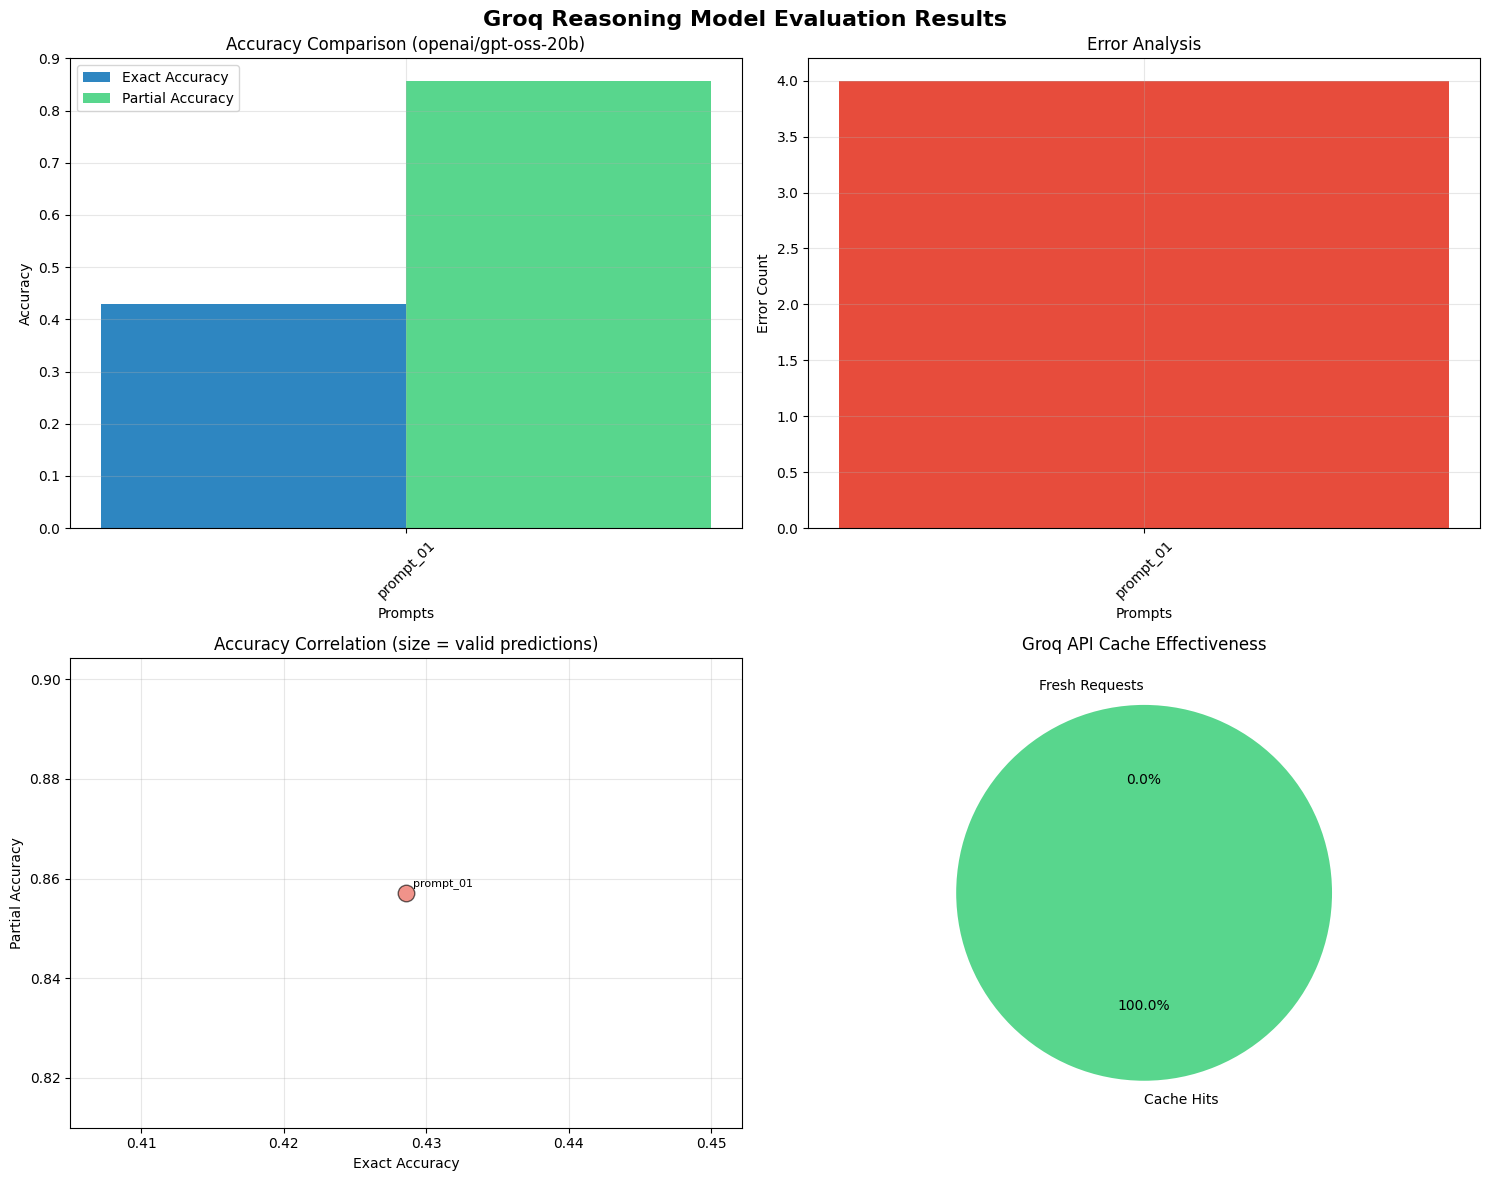


📊 GROQ SUMMARY STATISTICS
🏆 Best Prompt: prompt_01
📈 Best Exact Accuracy: 42.9%
📊 Average Exact Accuracy: 42.9%
📊 Average Partial Accuracy: 85.7%
💰 Total API Requests: 25
💾 Cache Efficiency: 50.0%
🧠 Model Used: openai/gpt-oss-20b
✅ Visualizations created successfully!

🔍 Analyzing Groq error patterns...

🔍 GROQ ERROR PATTERN ANALYSIS
❌ Total Errors: 0
🚫 Invalid Format: 4

🧠 Reasoning Model Results: 25
   📈 Reasoning Model Accuracy: 36.0%

✅ Exact Matches: 9
📊 Partial Only: 9

🔍 Common Partial Match Patterns:
   • hair: 3 partial matches
   • skin: 3 partial matches
   • body: 2 partial matches
   • makeup: 1 partial matches
✅ Error analysis completed!

📋 Creating detailed Groq report...

📋 DETAILED GROQ EVALUATION REPORT

🎯 EXECUTIVE SUMMARY
------------------------------
🧠 Model: openai/gpt-oss-20b
📊 Prompts Evaluated: 1
🏆 Best Performing Prompt: prompt_01
📈 Best Accuracy Achieved: 42.9%
📊 Average Exact Accuracy: 42.9%
📊 Average Partial Accuracy: 85.7%
❌ Total Errors: 4

📋 DETAILED B

In [9]:
# CELL 9: RUN ADVANCED ANALYSIS AND VISUALIZATION
# ============================================================================

print("\n" + "="*60)
print("📈 ADVANCED GROQ ANALYSIS AND VISUALIZATION")
print("="*60)

# Run advanced analysis if we have results
if 'comparison_results' in locals() and comparison_results:
    print("🎨 Creating Groq visualizations...")
    try:
        create_visualizations(comparison_results)
        print("✅ Visualizations created successfully!")
    except Exception as e:
        print(f"⚠️ Visualization error: {e}")
    
    print("\n🔍 Analyzing Groq error patterns...")
    try:
        analyze_error_patterns(comparison_results)
        print("✅ Error analysis completed!")
    except Exception as e:
        print(f"⚠️ Error analysis failed: {e}")
    
    print("\n📋 Creating detailed Groq report...")
    try:
        create_detailed_report(comparison_results)
        print("✅ Detailed report completed!")
    except Exception as e:
        print(f"⚠️ Report generation failed: {e}")
        
    print("\n✅ Advanced Groq analysis completed!")
else:
    print("❌ No results available for analysis")
    print("💡 Run cells 4-7 first to execute evaluations")
    
    # Show what's available
    print(f"\n🔍 Available variables:")
    if 'df' in locals():
        print(f"   ✅ df: Dataset loaded ({len(df)} products)")
        print(f"   ✅ test_df: Test sample ready ({len(test_df)} products)")
    else:
        print(f"   ❌ df: Dataset not loaded")
        
    if 'single_result' in locals() and single_result:
        print(f"   ✅ single_result: Single prompt evaluation available")
    else:
        print(f"   ❌ single_result: No single evaluation results")
        
    print(f"\n💡 Next steps:")
    print(f"   1. Make sure your data file exists: {config.DATASET_PATH}")
    print(f"   2. Create prompt files in: {config.PROMPTS_FOLDER}")
    print(f"   3. Set GROQ_API_KEY environment variable")
    print(f"   4. Run cells in order to generate results")

In [10]:
# CELL 10: INTERACTIVE TOOLS AND UTILITIES
# ============================================================================

def quick_test_single_product(product_description: str, prompt_name: str):
    """Test a single product with a specific prompt for quick debugging"""
    
    print(f"\n🔧 GROQ QUICK TEST: {prompt_name}")
    print("="*50)
    print(f"📝 Product: {product_description[:100]}...")
    print(f"🧠 Model: {config.MODEL}")
    
    # Load prompt
    system_prompt = load_prompt(prompt_name)
    if not system_prompt:
        print(f"❌ Could not load prompt: {prompt_name}")
        return None
    
    # Classify
    print("🔄 Classifying with Groq...")
    result = api_client.classify_product(
        product_description=product_description,
        system_prompt=system_prompt,
        prompt_name=prompt_name
    )
    
    print(f"\n📊 RESULT:")
    print(f"   🤖 Model: {result.get('model_used', config.MODEL)}")
    print(f"   🎯 Predicted: {result['predicted_category']}")
    print(f"   ⏱️ Latency: {result.get('latency', 0):.2f}s")
    print(f"   💾 From cache: {result.get('from_cache', False)}")
    print(f"   🔧 Status: {result.get('status', 'unknown')}")
    print(f"   🔗 API Provider: {result.get('api_provider', 'groq')}")
    
    if result.get('usage'):
        usage = result['usage']
        print(f"   📈 Tokens: {usage.get('total_tokens', 0)} total "
              f"({usage.get('prompt_tokens', 0)} prompt + {usage.get('completion_tokens', 0)} completion)")
    
    if result.get('raw_response'):
        print(f"\n📝 Raw response:")
        print(f"   {result['raw_response'][:200]}...")
    
    return result

def compare_prompts_on_single_product(product_description: str):
    """Compare all configured prompts on a single product"""
    
    print(f"\n🔍 GROQ PROMPT COMPARISON ON SINGLE PRODUCT")
    print("="*60)
    print(f"📝 Product: {product_description[:100]}...")
    print(f"🧠 Using Groq model: {config.MODEL}")
    
    results = {}
    
    for prompt_name in config.PROMPTS_TO_TEST:
        print(f"\n🧪 Testing: {prompt_name}")
        result = quick_test_single_product(product_description, prompt_name)
        if result:
            results[prompt_name] = result
    
    print(f"\n📊 GROQ COMPARISON SUMMARY:")
    print("-" * 40)
    for prompt_name, result in results.items():
        status_icon = "✅" if result['status'] == 'success' else "❌"
        cache_icon = "💾" if result.get('from_cache') else "🌐"
        latency = result.get('latency', 0)
        print(f"   {status_icon} {cache_icon} {prompt_name}: {result['predicted_category']} ({latency:.2f}s)")
    
    return results

def show_cache_stats():
    """Display detailed cache statistics"""
    
    print(f"\n💾 GROQ CACHE STATISTICS")
    print("="*30)
    
    stats = api_client.get_stats()
    cache_size = stats['cache_size']
    hit_rate = stats['hit_rate']
    requests = stats['requests_made']
    hits = stats['cache_hits']
    
    print(f"📊 Cache entries: {cache_size}")
    print(f"📈 Hit rate: {hit_rate}")
    print(f"📞 Total requests: {requests}")
    print(f"💾 Cache hits: {hits}")
    print(f"🌐 Fresh requests: {requests - hits}")
    print(f"🧠 Primary model: {stats['primary_model']}")
    print(f"🔗 API provider: {stats['api_provider']}")
    
    if cache_size > 0:
        print(f"💰 Estimated cost savings: {(hits / max(1, requests + hits)) * 100:.1f}%")
    
    print(f"📁 Cache file: {config.CACHE_FILE}")
    
    # Cache file size
    try:
        if os.path.exists(config.CACHE_FILE):
            size_bytes = os.path.getsize(config.CACHE_FILE)
            size_mb = size_bytes / (1024 * 1024)
            print(f"💽 Cache file size: {size_mb:.2f} MB")
        else:
            print(f"📝 Cache file not created yet")
    except Exception as e:
        print(f"⚠️ Could not read cache file: {e}")

def clear_cache():
    """Clear the evaluation cache"""
    
    print(f"\n🗑️ CLEARING GROQ CACHE")
    print("="*25)
    
    try:
        if os.path.exists(config.CACHE_FILE):
            os.remove(config.CACHE_FILE)
            print("✅ Cache file deleted")
        else:
            print("📝 No cache file to delete")
            
        # Reset in-memory cache
        api_client.cache = {}
        api_client.cache_hits = 0
        
        print("✅ In-memory cache cleared")
        print("💡 Fresh Groq API calls will be made for all future requests")
        
    except Exception as e:
        print(f"❌ Error clearing cache: {e}")

def test_groq_models():
    """Test available Groq models and their performance"""
    
    print(f"\n🧪 TESTING GROQ MODELS")
    print("="*30)
    
    try:
        # List available models
        models = groq_client.models.list()
        available_models = [model.id for model in models.data]
        
        print(f"📋 Available Groq models ({len(available_models)}):")
        for model in sorted(available_models):
            icon = "🧠" if config.is_reasoning_model(model) else "🤖"
            status = "✅" if model == config.MODEL else "  "
            print(f"   {status} {icon} {model}")
        
        # Test a few key models if we have test data
        if 'test_df' in locals() and len(test_df) > 0:
            print(f"\n🔬 Testing models with sample product...")
            sample_product = test_df.iloc[0]['concatenated_product']
            test_prompt = "Classify this product into category/subcategory format."
            
            models_to_test = [config.MODEL] + [m for m in config.ALTERNATIVE_MODELS if m in available_models][:2]
            
            for model in models_to_test:
                try:
                    start_time = time.time()
                    response = groq_client.chat.completions.create(
                        model=model,
                        messages=[{"role": "user", "content": f"{test_prompt}\n\nProduct: {sample_product[:100]}..."}],
                        max_tokens=50,
                        temperature=0.1
                    )
                    end_time = time.time()
                    
                    result = response.choices[0].message.content.strip()
                    latency = end_time - start_time
                    tokens = response.usage.total_tokens if response.usage else 0
                    
                    print(f"   ✅ {model}: {result[:30]}... ({latency:.2f}s, {tokens} tokens)")
                    
                except Exception as e:
                    print(f"   ❌ {model}: {str(e)[:50]}...")
        
        return True
        
    except Exception as e:
        print(f"❌ Model test failed: {e}")
        return False

print("✅ Interactive Groq tools and utilities loaded")

# Show available tools
print(f"\n🛠️ GROQ INTERACTIVE TOOLS AVAILABLE:")
print(f"   • quick_test_single_product(product, prompt_name)")
print(f"   • compare_prompts_on_single_product(product)")
print(f"   • show_cache_stats()")
print(f"   • clear_cache()")
print(f"   • test_groq_models()")

# Example usage
if 'test_df' in locals() and len(test_df) > 0 and len(config.PROMPTS_TO_TEST) > 0:
    print(f"\n💡 EXAMPLE USAGE:")
    sample_product = test_df.iloc[0]['concatenated_product']
    first_prompt = config.PROMPTS_TO_TEST[0]
    print(f"   quick_test_single_product('{sample_product[:50]}...', '{first_prompt}')")
    print(f"   compare_prompts_on_single_product('{sample_product[:50]}...')")
    print(f"   test_groq_models()")
else:
    print(f"\n💡 Load data first to see example usage")

✅ Interactive Groq tools and utilities loaded

🛠️ GROQ INTERACTIVE TOOLS AVAILABLE:
   • quick_test_single_product(product, prompt_name)
   • compare_prompts_on_single_product(product)
   • show_cache_stats()
   • clear_cache()
   • test_groq_models()

💡 EXAMPLE USAGE:
   quick_test_single_product('Babe-Fotoprotector Lip Protection SPF50 Invisible ...', 'prompt_01')
   compare_prompts_on_single_product('Babe-Fotoprotector Lip Protection SPF50 Invisible ...')
   test_groq_models()


In [11]:
# CELL 11: FINAL STATUS AND USAGE SUMMARY
# ============================================================================

print("\n" + "="*60)
print("🎉 GROQ NOTEBOOK EXECUTION COMPLETE")
print("="*60)

print("\n📊 EXECUTION SUMMARY:")
print(f"   ✅ Configuration: Loaded (Groq)")
print(f"   ✅ API Client: Initialized (Groq)")
print(f"   ✅ Data: {'Loaded' if 'df' in locals() and df is not None else 'Not loaded'}")
print(f"   ✅ Single Evaluation: {'Complete' if 'single_result' in locals() and single_result else 'Not run'}")
print(f"   ✅ Multi-Evaluation: {'Complete' if 'comparison_results' in locals() and comparison_results else 'Not run'}")
print(f"   ✅ LangSmith: {'Enabled' if LANGSMITH_ENABLED else 'Disabled'}")
print(f"   ✅ Visualizations: {'Available' if 'comparison_results' in locals() and comparison_results else 'Pending results'}")

# Show Groq-specific info
print(f"\n🧠 GROQ CONFIGURATION:")
print(f"   📋 Primary model: {config.MODEL}")
print(f"   🔄 Fallback models: {len(config.ALTERNATIVE_MODELS)}")
print(f"   ⚡ Base delay: {config.BASE_DELAY}s")
print(f"   💾 Cache enabled: {config.CACHE_RESULTS}")

if LANGSMITH_ENABLED:
    print(f"\n🔍 LangSmith Dashboard: https://smith.langchain.com/projects/{config.LANGCHAIN_PROJECT}")

# Show current status and next steps
print(f"\n💡 CURRENT STATUS:")

if 'comparison_results' in locals() and comparison_results:
    print("🎉 ✅ GROQ EVALUATION COMPLETED SUCCESSFULLY!")
    print(f"   📊 Best prompt: {comparison_results['best_result']['prompt_name']}")
    print(f"   📈 Best accuracy: {comparison_results['best_result']['metrics']['exact_accuracy']:.1%}")
    print(f"   📁 Results exported to: {config.RESULTS_FOLDER}")
    print(f"   🧠 Model used: {config.MODEL}")
    
    print(f"\n🔧 RECOMMENDED NEXT STEPS:")
    print("   1. 📊 Review the Groq-specific visualizations and error patterns above")
    print("   2. 📋 Examine exported CSV files for detailed analysis")
    print("   3. 🔍 Use interactive tools to test specific products")
    print("   4. ✍️ Optimize prompts based on reasoning model insights")
    print("   5. 🔄 Re-run evaluation with improved prompts")
    print("   6. 💡 Try different models (test_groq_models() to explore)")
    
elif 'df' in locals() and df is not None:
    print("📊 ✅ DATA LOADED - Ready for Groq evaluation")
    print(f"   📋 Dataset: {len(df)} products loaded")
    print(f"   🎯 Test sample: {len(test_df) if 'test_df' in locals() else 'Not created'} products")
    print(f"   🧠 Model ready: {config.MODEL}")
    
    print(f"\n🔧 NEXT STEPS:")
    print("   1. 📝 Create prompt files in the prompts/ folder")
    print("   2. ⚙️ Update PROMPTS_TO_TEST in config if needed")
    print("   3. 🚀 Run cells 5-7 to execute Groq evaluations")
    print("   4. 🧪 Use test_groq_models() to explore available models")
    
else:
    print("⏳ 🔧 GROQ SETUP REQUIRED")
    
    print(f"\n🔧 GROQ SETUP STEPS:")
    print("   1. 📁 Ensure data file exists at:", config.DATASET_PATH)
    print("   2. 📝 Create prompt files in:", config.PROMPTS_FOLDER)
    print("   3. ⚙️ Update PROMPTS_TO_TEST list with your prompt names")
    print("   4. 🔑 Set GROQ_API_KEY environment variable")
    print("   5. 💡 Get your API key from: https://console.groq.com/keys")
    print("   6. 🔄 Re-run cells 4-7")

# Show available resources
print(f"\n📚 AVAILABLE RESOURCES:")

print(f"\n   🔧 Configuration:")
print(f"      • config: All Groq settings and parameters")
print(f"      • api_client: Groq API client with caching")
print(f"      • groq_client: Direct Groq client instance")

if 'df' in locals():
    print(f"\n   📊 Data:")
    print(f"      • df: Full dataset ({len(df)} products)")
    if 'test_df' in locals():
        print(f"      • test_df: Test sample ({len(test_df)} products)")

print(f"\n   🧪 Evaluation Results:")
if 'single_result' in locals() and single_result:
    print(f"      • single_result: Single prompt evaluation")
if 'comparison_results' in locals() and comparison_results:
    print(f"      • comparison_results: Multi-prompt comparison")
else:
    print(f"      • (No evaluation results yet)")

print(f"\n   🛠️ Interactive Tools:")
print(f"      • quick_test_single_product(product, prompt)")
print(f"      • compare_prompts_on_single_product(product)")
print(f"      • show_cache_stats()")
print(f"      • clear_cache()")
print(f"      • test_groq_models()")

print(f"\n   📊 Analysis Functions:")
print(f"      • create_visualizations(comparison_results)")
print(f"      • analyze_error_patterns(comparison_results)")  
print(f"      • create_detailed_report(comparison_results)")

# Show cache and API stats
print(f"\n💾 CURRENT GROQ CACHE STATUS:")
try:
    show_cache_stats()
except:
    print("   (Cache stats not available)")

# Final tips
print(f"\n💡 GROQ OPTIMIZATION TIPS:")
print("   🎯 Start with deepseek-r1-distill-llama-70b for reasoning tasks")
print("   📝 Use structured prompts with step-by-step reasoning")
print("   🔄 Leverage model fallbacks for reliability")
print("   💾 Use caching for cost efficiency")
print("   ⚡ Groq is generally faster - consider larger batch sizes")
if not LANGSMITH_ENABLED:
    print("   🔍 Consider enabling LangSmith for deeper insights")

print(f"\n🆘 NEED HELP?")
print("   📖 Check the Groq documentation: https://console.groq.com/docs")
print("   🧪 Use test_groq_models() to explore available models")
print("   📊 Review example outputs and error patterns")
print("   💬 Groq community: https://discord.gg/groq")

print("\n" + "="*60)
print("🚀 Happy evaluating with Groq reasoning models! 🧠⚡")
print("="*60)


🎉 GROQ NOTEBOOK EXECUTION COMPLETE

📊 EXECUTION SUMMARY:
   ✅ Configuration: Loaded (Groq)
   ✅ API Client: Initialized (Groq)
   ✅ Data: Loaded
   ✅ Single Evaluation: Complete
   ✅ Multi-Evaluation: Complete
   ✅ LangSmith: Enabled
   ✅ Visualizations: Available

🧠 GROQ CONFIGURATION:
   📋 Primary model: openai/gpt-oss-20b
   🔄 Fallback models: 4
   ⚡ Base delay: 0.5s
   💾 Cache enabled: True

🔍 LangSmith Dashboard: https://smith.langchain.com/projects/reasoning-model-evaluation

💡 CURRENT STATUS:
🎉 ✅ GROQ EVALUATION COMPLETED SUCCESSFULLY!
   📊 Best prompt: prompt_01
   📈 Best accuracy: 42.9%
   📁 Results exported to: results
   🧠 Model used: openai/gpt-oss-20b

🔧 RECOMMENDED NEXT STEPS:
   1. 📊 Review the Groq-specific visualizations and error patterns above
   2. 📋 Examine exported CSV files for detailed analysis
   3. 🔍 Use interactive tools to test specific products
   4. ✍️ Optimize prompts based on reasoning model insights
   5. 🔄 Re-run evaluation with improved prompts
   6.